In [180]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [181]:
df = pd.read_csv("big_mart_sales.csv")

In [182]:
df

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976


In [183]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [184]:
df.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [185]:
#Ağırlığı olmayan ürünler listeden çıkarıldı
df = df.dropna(subset=["Item_Weight"])
df = df.reset_index(drop = True)

In [186]:
df

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...,...
7055,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
7056,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850
7057,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
7058,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976


In [187]:
df.Outlet_Size.value_counts()

Outlet_Size
Small     1860
Medium    1858
High       932
Name: count, dtype: int64

In [188]:
df

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...,...
7055,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
7056,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850
7057,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
7058,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976


In [189]:
df["Item_Fat_Content"] = df["Item_Fat_Content"].replace(
    {'LF': 'Low Fat', 'low fat': 'Low Fat', 'reg': 'Regular'}
)

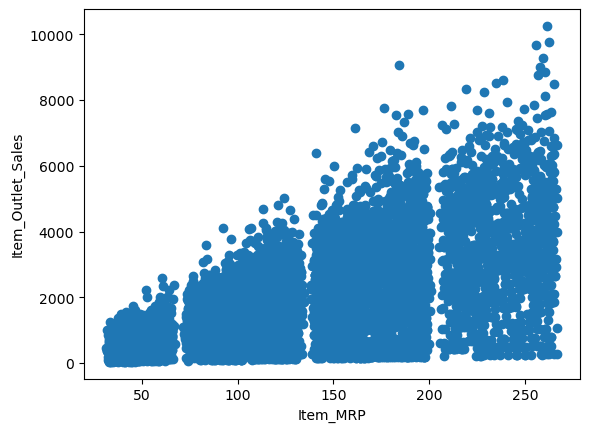

In [207]:
plt.scatter(df["Item_MRP"],df["Item_Outlet_Sales"])
plt.xlabel("Item_MRP")
plt.ylabel("Item_Outlet_Sales")
plt.show()

In [208]:
from sklearn.model_selection import train_test_split
X = df[["Item_MRP"]]
y = df["Item_Outlet_Sales"]

In [209]:
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.80,random_state=15)

In [210]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [211]:
X_test

array([[-1.3154282 ],
       [ 1.26604064],
       [-0.54683105],
       ...,
       [ 1.4744563 ],
       [-0.44640404],
       [-0.60779622]], shape=(1412, 1))

In [212]:
from sklearn.linear_model import LinearRegression
regression = LinearRegression()
regression.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [213]:
print("coefficient:",regression.coef_)
print("intercept:",regression.intercept_)
# y = coef_x + intercept_

coefficient: [944.2962309]
intercept: 2117.305180984419


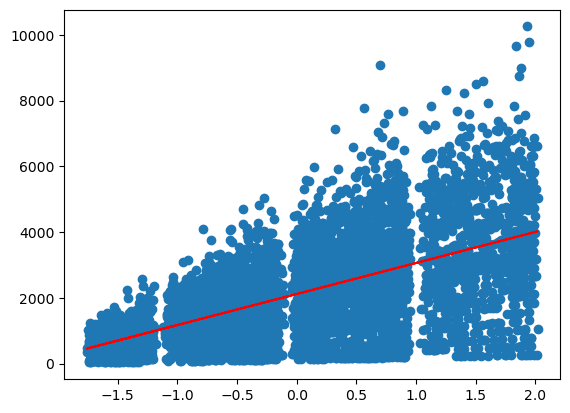

In [214]:
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train),"r")
plt.show()

In [215]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2,include_bias=True)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [216]:
X_train_poly

array([[ 1.        , -1.03476752,  1.07074382],
       [ 1.        , -1.19404693,  1.42574807],
       [ 1.        , -1.60716003,  2.58296338],
       ...,
       [ 1.        ,  0.64983554,  0.42228623],
       [ 1.        , -0.64091976,  0.41077814],
       [ 1.        , -1.56554369,  2.45092705]], shape=(5648, 3))

In [217]:
regression = LinearRegression()
regression.fit(X_train_poly,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [309]:
from sklearn.metrics import r2_score,mean_squared_error
y_pred = regression.predict(X_test_poly)
score = r2_score(y_test,y_pred)
print(score)
#ürünün fiyatının %4.1 total kaarı etkilediği anlaşılır.

0.04162327928620346


In [219]:
regression.coef_

array([  0.        , 946.09527849, -13.62079063])

In [220]:
regression.intercept_

np.float64(2130.9259716168817)

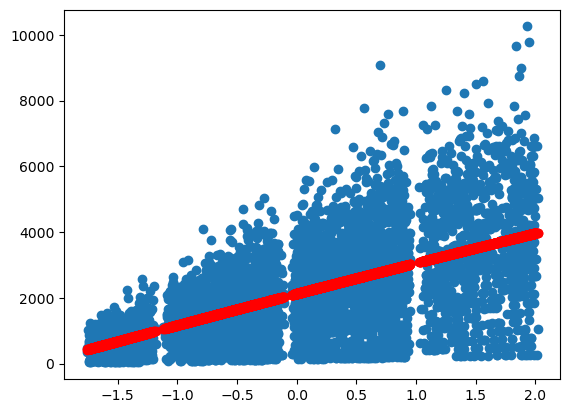

In [221]:
plt.scatter(X_train,y_train)
#best Fit line
plt.scatter(X_train,regression.predict(X_train_poly),color="r")
plt.show()

In [264]:
df["Outlet_Location_Type"] = df["Outlet_Location_Type"].replace({"Tier ":""},regex=True).astype(int)

In [265]:
from sklearn.model_selection import train_test_split
X = df[["Outlet_Location_Type"]]
y = df["Item_Outlet_Sales"]
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.80,random_state=42)

In [270]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

from sklearn.linear_model import LinearRegression
regression = LinearRegression()
regression.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [308]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2,include_bias=True)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

regression = LinearRegression()
regression.fit(X_train_poly,y_train)

from sklearn.metrics import r2_score,mean_squared_error
y_pred = regression.predict(X_test_poly)
score = r2_score(y_test,y_pred)
print(score)
#ürünün fiyatının % total kaarı etkilediği anlaşılır.

0.04162327928620346


In [295]:
#Mağazanın Lokasyonu Maximum %4 fark edebilir yani dükkanın konumu ürünün satışı için çokda önemli bir kriter değil!

In [296]:
print(df.groupby("Outlet_Location_Type")["Item_Outlet_Sales"].mean())
#tier1 ve tier 2 daha çok satış yapmış

Outlet_Location_Type
1    2313.099451
2    2323.990559
3    1732.019288
Name: Item_Outlet_Sales, dtype: float64


In [297]:
features = ['Item_MRP', 'Outlet_Type', 'Outlet_Location_Type']
X_Poly = pd.get_dummies(df[features],drop_first=True)
y_poly = df['Item_Outlet_Sales']

In [304]:
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_Poly, y_poly, train_size=0.80, random_state=42
)

In [305]:
multi_reg = LinearRegression()
multi_reg.fit(X_train_p, y_train_p)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [306]:
y_pred_p = multi_reg.predict(X_test_p)
multi_score = r2_score(y_test_p, y_pred_p)

In [310]:
print("Çoklu Regresyon R2 Skoru:", multi_score)
print("coefficient:", multi_reg.coef_)
print("intercept:", multi_reg.intercept_)
#r2 %54 e kadar çıkarılıyor.

Çoklu Regresyon R2 Skoru: 0.5390850638585298
coefficient: [1.50725964e+01 1.39091148e-01 1.93930784e+03 1.63824099e+03]
intercept: -1762.2316601956763
